<a href="https://colab.research.google.com/github/nivetha-s2/Credit-card-fraud-detection/blob/main/ev_fleet_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [202]:
df = pd.read_csv("ev_fleet_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [203]:
print("Shape:", df.shape)
df.head()

Shape: (10000, 18)


,S_No,Date,Car_ID,EV_Name,Manufacturer,Driver_Name,Safe_Speed,Current_Speed,Overspeed_Violation,Status,Battery_Percentage,Range_Full_Charge_KM,Expected_Remaining_Distance,Charging_Time_Hours,Distance_Covered_Today,Revenue_Generated_Today,Working_Condition,Maintenance_Cost_Today
0,1,2025-07-01,EV028,Comet EV Play,MG,Ramesh Iyer,80,0,0,Idle,35,200,70.0,0.0,0.00,0.00,1,0.0
1,2,2025-07-01,EV041,Atto 3,BYD,Amit Malhotra,65,0,0,Garage,14,320,44.8,0.0,0.00,0.00,1,0.0
2,3,2025-07-01,EV010,Nexon EV Prime,Tata,Naveen Patel,65,0,0,Garage,8,380,30.4,0.0,0.00,0.00,1,0.0
3,4,2025-07-01,EV012,e2oPlus,Mahindra,Dinesh Chauhan,65,64,0,Running,93,300,279.0,0.0,250.21,3627.61,1,0.0
4,5,2025-07-01,EV044,Atto 3 Premium,BYD,Manoj Sharma,80,56,0,Running,69,320,220.8,0.0,275.51,3723.98,1,0.0


In [204]:
status_count = df['Status'].value_counts()
print("\n--- i) Vehicle Status Count ---")
print(status_count)


--- i) Vehicle Status Count ---
Status
Running     4474
Charging    2039
Idle        1974
Garage      1513
Name: count, dtype: int64


In [205]:
garage_count = df[df['Status'] == 'Garage'].shape[0]
print("\n--- ii) Garage Vehicles Count ---")
print(garage_count)


--- ii) Garage Vehicles Count ---
1513


In [206]:
charging_count = df[df['Status'] == 'Charging'].shape[0]
print("\n--- iii) Vehicles in Charging ---")
print(charging_count)


--- iii) Vehicles in Charging ---
2039


In [207]:
running_count = df[df['Status'] == 'Running'].shape[0]
print("\n--- iv) Vehicles Running ---")
print(running_count)


--- iv) Vehicles Running ---
4474


In [208]:
manufacturers = df['Manufacturer'].unique()
print("\n--- v) Manufacturers ---")
print(manufacturers, "| Count:", len(manufacturers))


--- v) Manufacturers ---
['MG' 'BYD' 'Tata' 'Mahindra' 'Hyundai'] | Count: 5


In [209]:
manuf_count = df.groupby('Manufacturer')['Car_ID'].nunique()
print("\n--- vi) Manufacturer-wise Vehicle Count ---")
print(manuf_count)


--- vi) Manufacturer-wise Vehicle Count ---
Manufacturer
BYD         10
Hyundai     10
MG          10
Mahindra    10
Tata        10
Name: Car_ID, dtype: int64


In [210]:
df['Month'] = df['Date'].dt.to_period('M')
month_revenue_per_car = df.groupby(['Month', 'Car_ID'])['Revenue_Generated_Today'].sum().reset_index()
print("\n--- vii) Month-wise Revenue per Car (sample) ---")
print(month_revenue_per_car.head(10))


--- vii) Month-wise Revenue per Car (sample) ---
     Month Car_ID  Revenue_Generated_Today
0  2025-07  EV001                 30428.85
1  2025-07  EV002                  9902.22
2  2025-07  EV003                 17739.60
3  2025-07  EV004                 12144.66
4  2025-07  EV005                 11930.34
5  2025-07  EV006                  5723.76
6  2025-07  EV007                 18289.37
7  2025-07  EV008                 11757.75
8  2025-07  EV009                 28122.74
9  2025-07  EV010                 12732.50


In [211]:
month_revenue_total = df.groupby('Month')['Revenue_Generated_Today'].sum()
print("\nTotal Revenue by Month:")
print(month_revenue_total)


Total Revenue by Month:
Month
2025-07    824394.03
2025-08    686933.70
2025-09    673109.38
2025-10    705649.22
2025-11    691882.79
2025-12    719957.90
2026-01    732519.73
2026-02    646549.89
2026-03    672431.52
2026-04    646058.38
2026-05    700962.07
2026-06    689138.83
Freq: M, Name: Revenue_Generated_Today, dtype: float64


In [212]:
month_maint_per_car = df.groupby(['Month', 'Car_ID'])['Maintenance_Cost_Today'].sum().reset_index()
print("\n--- viii) Month-wise Maintenance Cost per Car (sample) ---")
print(month_maint_per_car.head(10))


--- viii) Month-wise Maintenance Cost per Car (sample) ---
     Month Car_ID  Maintenance_Cost_Today
0  2025-07  EV001                 2042.78
1  2025-07  EV002                 2100.83
2  2025-07  EV003                 9886.02
3  2025-07  EV004                  986.75
4  2025-07  EV005                 2385.27
5  2025-07  EV006                 1425.39
6  2025-07  EV007                    0.00
7  2025-07  EV008                 5202.11
8  2025-07  EV009                 9050.88
9  2025-07  EV010                 2155.45


In [213]:
driver_per_car = df.groupby('Car_ID')['Driver_Name'].nunique()
violations = driver_per_car[driver_per_car > 1]
print("\n--- ix) Hypothesis Check: One car -> One driver only ---")
print("Cars with more than 1 driver (should be empty if hypothesis holds):")
print(violations)


--- ix) Hypothesis Check: One car -> One driver only ---
Cars with more than 1 driver (should be empty if hypothesis holds):
Series([], Name: Driver_Name, dtype: int64)


In [214]:
driver_revenue = df.groupby('Driver_Name')['Revenue_Generated_Today'].sum().sort_values(ascending=False)
print("\nDriver with MAX revenue:", driver_revenue.idxmax(), "->", driver_revenue.max())
print("Driver with MIN revenue:", driver_revenue.idxmin(), "->", driver_revenue.min())


Driver with MAX revenue: Nitin Reddy -> 232356.63
Driver with MIN revenue: Rakesh Rao -> 97319.92


In [215]:
overspeed_by_driver = df.groupby('Driver_Name')['Overspeed_Violation'].sum().sort_values(ascending=False)
print("\n--- x) Overspeed Violations by Driver (Top 5) ---")
print(overspeed_by_driver.head(5))
print("\nDriver with MAX overspeed violations:", overspeed_by_driver.idxmax(), "->", overspeed_by_driver.max())



--- x) Overspeed Violations by Driver (Top 5) ---
Driver_Name
Ramesh Iyer     26
Manish Rao      26
Ravi Patel      24
Lokesh Gupta    23
Chetan Singh    22
Name: Overspeed_Violation, dtype: int64

Driver with MAX overspeed violations: Ramesh Iyer -> 26


In [216]:
battery_distance = df[['Car_ID', 'Date', 'Battery_Percentage', 'Expected_Remaining_Distance']]
print("\n--- xi) Battery % and Expected Travel Distance (sample) ---")
print(battery_distance.head(10))


--- xi) Battery % and Expected Travel Distance (sample) ---
  Car_ID       Date  Battery_Percentage  Expected_Remaining_Distance
0  EV028 2025-07-01                  35                         70.0
1  EV041 2025-07-01                  14                         44.8
2  EV010 2025-07-01                   8                         30.4
3  EV012 2025-07-01                  93                        279.0
4  EV044 2025-07-01                  69                        220.8
5  EV029 2025-07-01                  53                        116.6
6  EV039 2025-07-01                  79                        316.0
7  EV014 2025-07-01                  63                        252.0
8  EV008 2025-07-01                  69                        186.3
9  EV045 2025-07-01                  55                        110.0


In [217]:
features = [
    'Current_Speed', 'Overspeed_Violation',
    'Battery_Percentage', 'Range_Full_Charge_KM',
    'Expected_Remaining_Distance', 'Charging_Time_Hours',
    'Distance_Covered_Today', 'Revenue_Generated_Today',
    'Maintenance_Cost_Today'
]
le_manuf = LabelEncoder()
df['Manufacturer_enc'] = le_manuf.fit_transform(df['Manufacturer'])
features.append('Manufacturer_enc')
X = df[features]

In [218]:

sample_out = pd.DataFrame({
    'Actual': le_status.inverse_transform(y_test[:10]),
    'Predicted': le_status.inverse_transform(pred_status[:10])
})
print("Sample Predictions (Status):")
print(sample_out)

Sample Predictions (Status):
     Actual Predicted
0  Charging  Charging
1   Running   Running
2  Charging  Charging
3   Running   Running
4   Running   Running
5  Charging  Charging
6      Idle    Garage
7   Running   Running
8   Running   Running
9   Running   Running


In [219]:
SAFE_SPEED_LIMIT = 100
df['Overspeed_Violation_Fixed'] = (df['Current_Speed'] > SAFE_SPEED_LIMIT).astype(int)
y_ov = df['Overspeed_Violation_Fixed']
X3 = df[['Current_Speed']]
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y_ov, test_size=0.2, random_state=42, stratify=y_ov
)
model_ov = RandomForestClassifier(n_estimators=100, random_state=42)
model_ov.fit(X_train3, y_train3)
pred_ov = model_ov.predict(X_test3)
print("\n=== MODEL 3: Predicting Overspeed Violation (Fixed Limit = 100) ===")
print(classification_report(y_test3, pred_ov))


=== MODEL 3: Predicting Overspeed Violation (Fixed Limit = 100) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1980
           1       1.00      1.00      1.00        20

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000




--- Feature Importance -----
Charging_Time_Hours            0.295504
Distance_Covered_Today         0.181112
Current_Speed                  0.153678
Revenue_Generated_Today        0.147603
Expected_Remaining_Distance    0.076687
Battery_Percentage             0.069161
Maintenance_Cost_Today         0.030774
Manufacturer_enc               0.022550
Range_Full_Charge_KM           0.017001
Overspeed_Violation            0.005930
dtype: float64


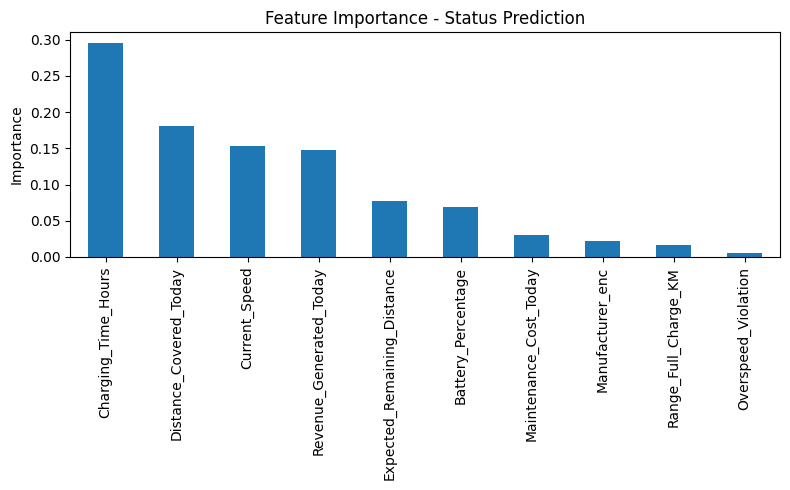

In [220]:
importances = pd.Series(model_status.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Feature Importance -----")
print(importances)
plt.figure(figsize=(8,5))
importances.plot(kind='bar')
plt.title("Feature Importance - Status Prediction")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [224]:
unique_vehicles = df['Car_ID'].unique()
print("Total Unique Vehicles:", len(unique_vehicles))
print(unique_vehicles)

Total Unique Vehicles: 50
['EV028' 'EV041' 'EV010' 'EV012' 'EV044' 'EV029' 'EV039' 'EV014' 'EV008'
 'EV045' 'EV007' 'EV018' 'EV031' 'EV004' 'EV013' 'EV048' 'EV035' 'EV046'
 'EV020' 'EV011' 'EV037' 'EV047' 'EV002' 'EV001' 'EV050' 'EV006' 'EV043'
 'EV022' 'EV024' 'EV030' 'EV015' 'EV042' 'EV026' 'EV005' 'EV009' 'EV034'
 'EV016' 'EV003' 'EV025' 'EV023' 'EV021' 'EV049' 'EV036' 'EV040' 'EV019'
 'EV027' 'EV038' 'EV017' 'EV033' 'EV032']


In [225]:
unique_vehicle_details = df[['Car_ID', 'EV_Name', 'Manufacturer']].drop_duplicates().reset_index(drop=True)
print(unique_vehicle_details)

   Car_ID                EV_Name Manufacturer
0   EV028          Comet EV Play           MG
1   EV041                 Atto 3          BYD
2   EV010         Nexon EV Prime         Tata
3   EV012                e2oPlus     Mahindra
4   EV044         Atto 3 Premium          BYD
5   EV029           ZS EV Select           MG
6   EV039       Kona Electric EX      Hyundai
7   EV014              XUV400 EL     Mahindra
8   EV008            Tiago EV XZ         Tata
9   EV045            e6 Superior          BYD
10  EV007           Tigor EV Max         Tata
11  EV018          XUV400 EC Pro     Mahindra
12  EV031          Kona Electric      Hyundai
13  EV004               Punch EV         Tata
14  EV013                eVerito     Mahindra
15  EV048            e6 Standard          BYD
16  EV035    Kona Electric Smart      Hyundai
17  EV046       Seal Performance          BYD
18  EV020             eVerito D6     Mahindra
19  EV011                 XUV400     Mahindra
20  EV037       Kona Electric SX  

In [221]:
print("\n\n================ FLEET SUMMARY DASHBOARD ================")
print(f"Total Vehicles Tracked      : {df['Car_ID'].nunique()}")
print(f"Running                     : {running_count}")
print(f"Idle                        : {(df['Status']=='Idle').sum()}")
print(f"Garage                      : {garage_count}")
print(f"Charging                    : {charging_count}")
print(f"Manufacturers (>=4 check)   : {len(manufacturers)} -> {list(manufacturers)}")
print(f"Top Revenue Driver          : {driver_revenue.idxmax()} (₹{driver_revenue.max():.2f})")
print(f"Lowest Revenue Driver       : {driver_revenue.idxmin()} (₹{driver_revenue.min():.2f})")
print(f"Most Overspeed Violations   : {overspeed_by_driver.idxmax()} ({overspeed_by_driver.max()} times)")
print("===========================================================")



================ FLEET SUMMARY DASHBOARD ================
Total Vehicles Tracked      : 50
Running                     : 4474
Idle                        : 1974
Garage                      : 1513
Charging                    : 2039
Manufacturers (>=4 check)   : 5 -> ['MG', 'BYD', 'Tata', 'Mahindra', 'Hyundai']
Top Revenue Driver          : Nitin Reddy (₹232356.63)
Lowest Revenue Driver       : Rakesh Rao (₹97319.92)
Most Overspeed Violations   : Ramesh Iyer (26 times)


                             Current_Speed  Overspeed_Violation  \
Current_Speed                         1.00                 0.61   
Overspeed_Violation                   0.61                 1.00   
Battery_Percentage                    0.00                -0.01   
Range_Full_Charge_KM                  0.01                -0.01   
Expected_Remaining_Distance           0.01                -0.01   
Charging_Time_Hours                  -0.35                -0.13   
Distance_Covered_Today                0.70                 0.25   
Revenue_Generated_Today               0.67                 0.24   
Working_Condition                     0.00                 0.01   
Maintenance_Cost_Today               -0.00                -0.01   

                             Battery_Percentage  Range_Full_Charge_KM  \
Current_Speed                              0.00                  0.01   
Overspeed_Violation                       -0.01                 -0.01   
Battery_Percentage                         

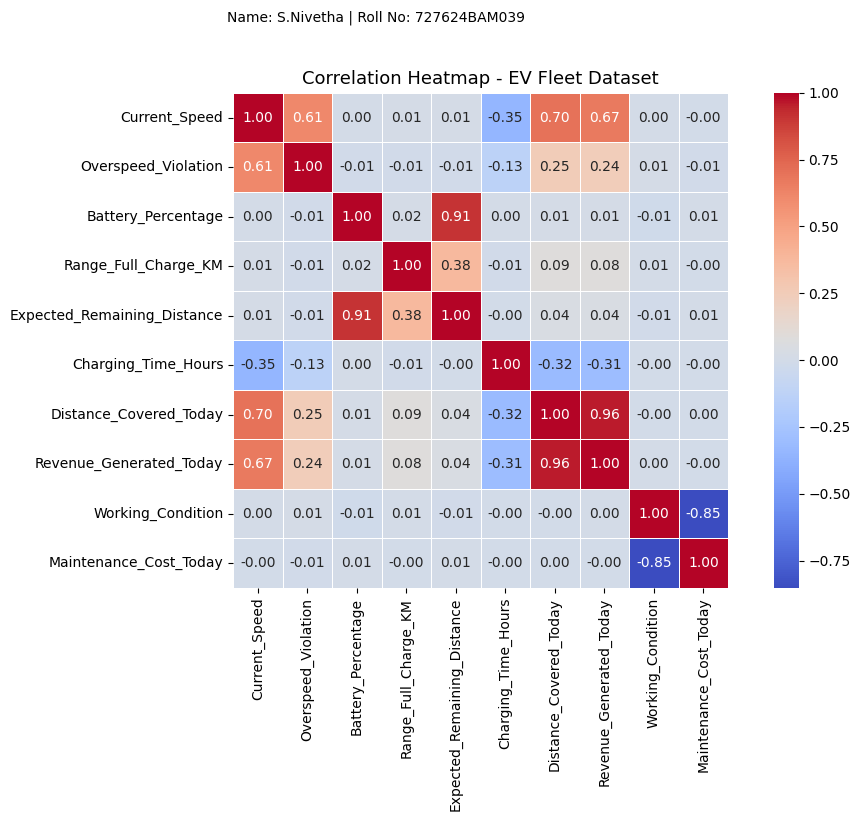

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = ['Current_Speed','Overspeed_Violation','Battery_Percentage',
'Range_Full_Charge_KM','Expected_Remaining_Distance','Charging_Time_Hours',
'Distance_Covered_Today','Revenue_Generated_Today','Working_Condition','Maintenance_Cost_Today']
corr = df[numeric_cols].corr()
print(corr.round(2))
plt.figure(figsize=(11,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.suptitle('Name: S.Nivetha | Roll No: 727624BAM039', fontsize=10, y=1.02)
plt.title('Correlation Heatmap - EV Fleet Dataset', fontsize=13)
plt.tight_layout()
plt.show()

In [226]:
total_maintenance = df['Maintenance_Cost_Today'].sum()
print("Total Maintenance Cost (all cars, all days):", round(total_maintenance, 2))

Total Maintenance Cost (all cars, all days): 4470797.4


In [227]:
maintenance_per_car = df.groupby('Car_ID')['Maintenance_Cost_Today'].sum().sort_values(ascending=False)
print(maintenance_per_car)

Car_ID
EV017    151898.93
EV027    142282.72
EV012    116792.11
EV006    116599.22
EV020    113429.52
EV029    113319.12
EV033    111333.17
EV048    109759.96
EV035    107548.16
EV005    107382.01
EV046    106441.20
EV032    106039.67
EV050    105096.71
EV041    104613.39
EV047    103405.95
EV003    102466.04
EV022    101005.80
EV026     99883.81
EV045     95078.18
EV031     94554.37
EV009     93888.97
EV040     93685.22
EV010     92671.63
EV008     90479.20
EV044     90437.69
EV023     89940.70
EV011     88158.83
EV036     86857.60
EV043     86798.83
EV049     85474.65
EV039     81665.13
EV037     81172.70
EV038     81051.97
EV001     80091.89
EV015     78045.70
EV024     77262.00
EV021     76298.99
EV030     74796.00
EV014     74754.53
EV028     74268.41
EV042     68554.23
EV004     66551.71
EV034     65440.90
EV013     64535.27
EV019     62803.36
EV025     59881.71
EV002     55584.48
EV016     52321.04
EV018     45839.75
EV007     42554.27
Name: Maintenance_Cost_Today, dtype: float6

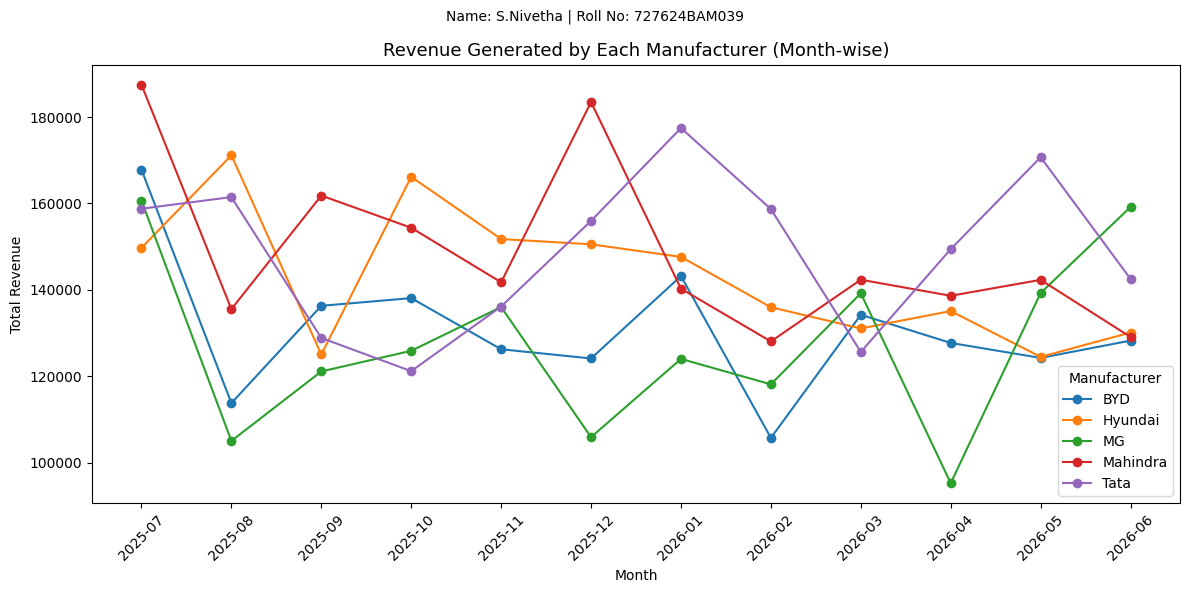

In [223]:
import matplotlib.pyplot as plt
df['Month'] = df['Date'].dt.to_period('M').astype(str)
revenue_by_manuf_month = df.groupby(['Month','Manufacturer'])['Revenue_Generated_Today'].sum().unstack()
plt.figure(figsize=(12,6))
for manuf in revenue_by_manuf_month.columns:
    plt.plot(revenue_by_manuf_month.index, revenue_by_manuf_month[manuf], marker='o', label=manuf)
plt.suptitle('Name: S.Nivetha | Roll No: 727624BAM039', fontsize=10, x=0.5, y=0.98)
plt.title('Revenue Generated by Each Manufacturer (Month-wise)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Manufacturer')
plt.tight_layout()
plt.show()

In [231]:
!git config --global user.email "nivethashanmugasundaram28@gmail.com"
!git config --global user.name "nivetha-s2"

In [234]:
!git clone https://github.com/nivetha-s2/ev_fleet_.git


Cloning into 'ev_fleet_'...


In [235]:
%cd ev_fleet_


/content/ev_fleet_


In [236]:
!cp /content/ev_fleet_dataset.csv /content/ev_fleet_/
!cp /content/ev_fleet_dataset.ipynb /content/ev_fleet_/


cp: cannot stat '/content/ev_fleet_dataset.ipynb': No such file or directory
